# Premières mesures au labo : incertitudes et premier rapport

**Notebook-rapport guidé — TP 1**

**Énoncé :** [Premières mesures au labo](https://www.pcsi2.net/fabert/wp-content/uploads/physique/Premieres-mesures-au-labo.pdf)  
**Cours :** [Incertitudes](https://www.pcsi2.net/fabert/wp-content/uploads/physique/Incertitudes.pdf)

Noms :
Date :


> **Correction illustrative — valeurs non imposées.**  
> Les données et résultats numériques ci-dessous correspondent à un ressort d’exemple. Une copie étudiante doit être évaluée à partir des mesures de son propre binôme, et non par comparaison à ces nombres.



## Prise en main du notebook

Bravo, vous voici devant un **notebook** : il alterne des cellules de texte et des cellules de code.

- Cliquez une fois sur une cellule pour la sélectionner.
- Double-cliquez sur une cellule de texte pour la modifier.
- Exécutez ou validez une cellule avec `Shift + Entrée`.
- Une cellule de texte est mise en forme ; une cellule de code est exécutée par Python.

Essayez avec la cellule suivante. Elle doit afficher une courte phrase sous la cellule.


In [1]:
print("Le notebook est prêt.")


Le notebook est prêt.



## Mode d’emploi et principe du rapport

Ce notebook constitue à la fois un support de **TP-cours** et votre premier rapport guidé. Il doit permettre à une personne qui n’a pas assisté à la séance de comprendre ce qui a été étudié, comment les mesures ont été réalisées, comment elles ont été exploitées et ce qui peut être conclu.

- Remplacez les `?` des cellules de code par les mesures de votre binôme.
- Exécutez les cellules dans l’ordre avec `Shift + Entrée`.
- Rédigez les réponses avec vos propres résultats : ils dépendent de votre ressort.
- Intégrez les photographies dans le notebook avec `attachment:` ; un lien vers un fichier extérieur ne suffit pas.
- Donnez les unités et présentez chaque résultat sous la forme valeur ± incertitude-type.

Les premières étapes sont volontairement détaillées. Les TP suivants vous demanderont de réinvestir ces méthodes avec davantage d’autonomie.


## Objectifs du TP-cours

Cette séance suit le fil du cours **Incertitudes**. Elle doit permettre de :

- observer la variabilité d’un mesurage et comprendre qu’elle ne constitue pas une erreur ;
- déterminer un meilleur estimateur et une incertitude-type ;
- distinguer une variabilité observée (type A) d’une incertitude évaluée par un intervalle (type B) ;
- écrire correctement le résultat d’un mesurage ;
- utiliser une simulation Monte-Carlo pour composer les incertitudes ;
- utiliser l’écart normalisé pour comparer deux résultats ;
- vérifier une loi affine et déterminer la raideur du ressort par une seconde méthode.

Les valeurs numériques dépendent du ressort de votre binôme : elles ne sont pas comparées à celles d’un ressort du professeur.


## Parcours de la séance

Le notebook suit l’ordre du TP-cours :

1. observer la variabilité de la mesure de la période ;
2. calculer moyenne, écart-type et incertitude sur la moyenne ;
3. simuler une variabilité observée avec une loi normale ;
4. écrire le résultat de la mesure de $T$ ;
5. traiter la masse comme une mesure de type B avec une loi uniforme ;
6. composer les incertitudes pour déterminer $k$ ;
7. vérifier la loi affine de Hooke et obtenir une seconde valeur de $k$ ;
8. comparer quantitativement les deux résultats.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

N = 10_000
g = 9.81  # m.s^-2


## 1. Variabilité observée : mesure de la période

Le système masse-ressort vertical constitue un oscillateur mécanique. On commence par mesurer sa période $T$.

Répéter exactement le même mesurage conduit naturellement à des valeurs légèrement différentes : cette **variabilité fait partie du mesurage** et ne constitue pas une erreur.


<!-- dynamic-objective-response -->
<div class="alert alert-block" style="background-color: #F5F8FC; border-color: #DCE6F0; color: #202124;">

### Objectif de la manipulation dynamique

Avant de commencer, reformulez ce que cette manipulation doit permettre de déterminer et indiquez les grandeurs qu’il faudra mesurer.

### Réponse :

Déterminer la constante de raideur $k$ du ressort à partir de la masse suspendue $m$ et de la période $T$ de ses petites oscillations verticales.
</div>


<!-- dynamic-protocol-response -->
<div class="alert alert-block" style="background-color: #F5F8FC; border-color: #DCE6F0; color: #202124;">

### Protocole dynamique construit en classe

Reformulez le protocole avec suffisamment de précision : mise en oscillation, amplitude, nombre de périodes chronométrées, répétitions, repère choisi pour déclencher et arrêter, précautions et principales sources d’incertitude.

### Réponse :

Suspendre une masse de 50 g sans dépasser le domaine élastique, l’écarter verticalement d’environ 1 à 2 cm puis la lâcher sans vitesse initiale. Après une oscillation, chronométrer dix périodes entre deux passages au même repère et dans le même sens. Répéter le mesurage plusieurs fois. Mesurer plusieurs périodes réduit l’effet du temps de réaction ; conserver de faibles oscillations verticales limite les écarts au modèle.
</div>


<!-- dynamic-protocol-schematic -->
### Schéma expérimental du binôme

Photographiez **votre propre schéma**, tracé sur une feuille sur la paillasse, puis insérez-le ici. Le schéma doit faire apparaître le ressort, la masse, le repère utilisé pour le chronométrage et les grandeurs utiles.

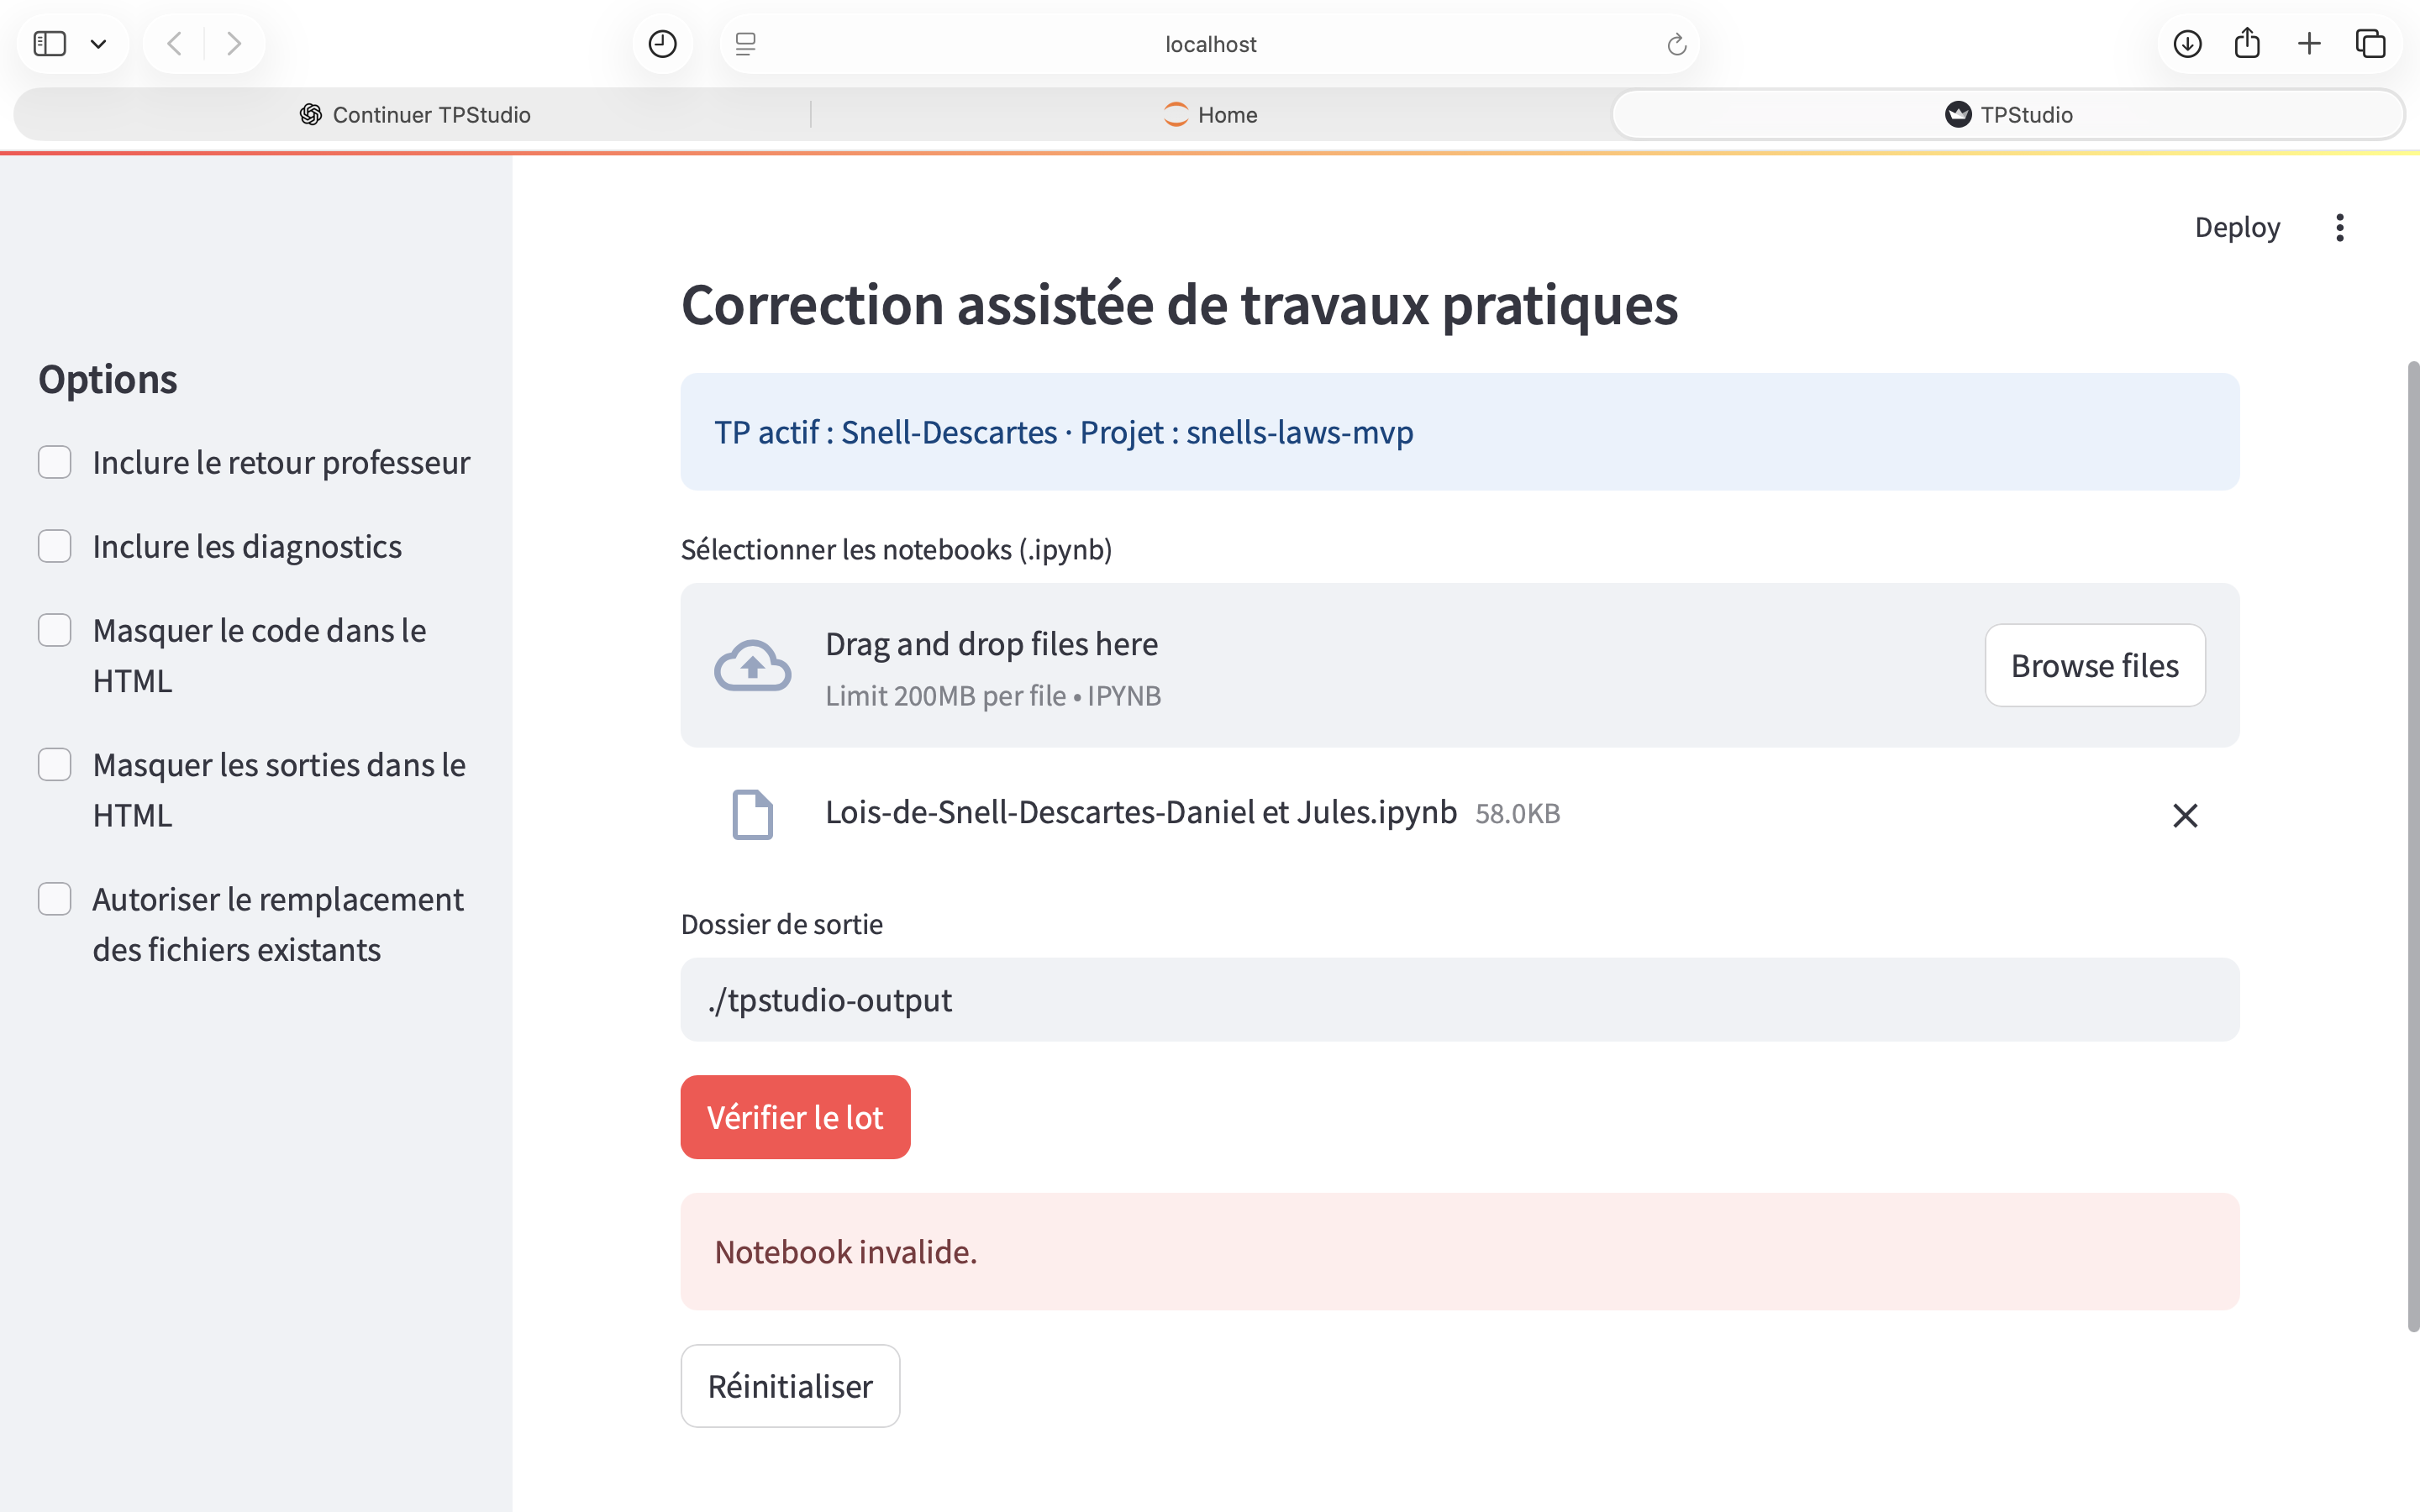


### Mesures répétées de dix périodes

Chronométrer dix périodes réduit l’influence du temps de réaction. Répétez ce mesurage plusieurs fois, toujours entre deux passages au même repère et dans le même sens. Le tableau `dix_T` contient les durées de $10T$, en secondes.


In [3]:
dix_T = np.array([6.19, 6.64, 6.78, 6.99, 6.88, 6.86, 6.84, 6.84], dtype=float)


In [4]:
T_values = dix_T / 10
T = T_values
print(T)


[0.619 0.664 0.678 0.699 0.688 0.686 0.684 0.684]


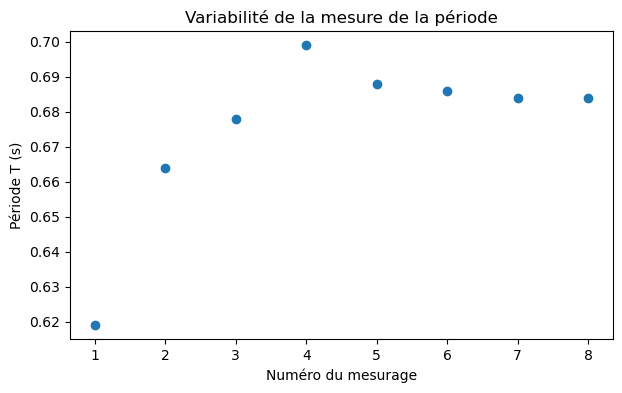

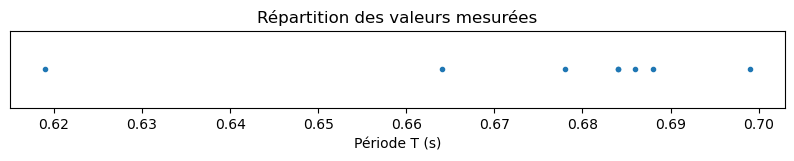

In [5]:
# Premier tracé : évolution des valeurs au fil des répétitions
plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(T) + 1), T, "o")
plt.xlabel("Numéro du mesurage")
plt.ylabel("Période T (s)")
plt.title("Variabilité de la mesure de la période")
plt.show()

# Représentation de la figure 2 du TP-cours Incertitudes
plt.figure(figsize=(10,1)) # création du graphique en précisant sa taille
plt.title("Répartition des valeurs mesurées") # titre du graphique
plt.plot(T,0*T,'.') # tracé (différentes valeurs de T en abscisse et 0 en ordonnée)
plt.xlabel("Période T (s)")
plt.yticks([])
plt.show()


## 2. Meilleur estimateur et incertitude-type

Pour une série de $n$ observations :

- la moyenne `T.mean()` fournit le meilleur estimateur $\overline T$ ;
- l’écart-type `T.std(ddof=1)` caractérise la variabilité d’un mesurage unique, notée ici $u(T)$ ;
- l’incertitude-type sur la moyenne vaut $u(\overline T)=u(T)/\sqrt{n}$.

Le résultat final de la période moyenne utilisera $u(\overline T)$.


In [6]:
T_mean = T_values.mean()
u_T_single = T_values.std(ddof=1)
u_T = u_T_single / np.sqrt(len(T))

print("Moyenne de T =", round(T_mean, 4), "s")
print("Écart-type d'un mesurage =", round(u_T_single, 4), "s")
print("Incertitude-type sur la moyenne =", round(u_T, 4), "s")


Moyenne de T = 0.6752 s
Écart-type d'un mesurage = 0.0248 s
Incertitude-type sur la moyenne = 0.0088 s


## 3. Simulation d’une variabilité observée - type A

La commande `np.random.normal(x, ux, N)` génère $N$ valeurs réparties selon une loi normale de moyenne `x` et d’écart-type `ux`.

On simule ici les valeurs raisonnablement attribuables à **un chronométrage** de la période, à partir de $\overline T$ et de l’écart-type observé. L’histogramme doit retrouver approximativement ces deux paramètres.


Moyenne simulée = 0.6754 s
Écart-type simulé = 0.0251 s


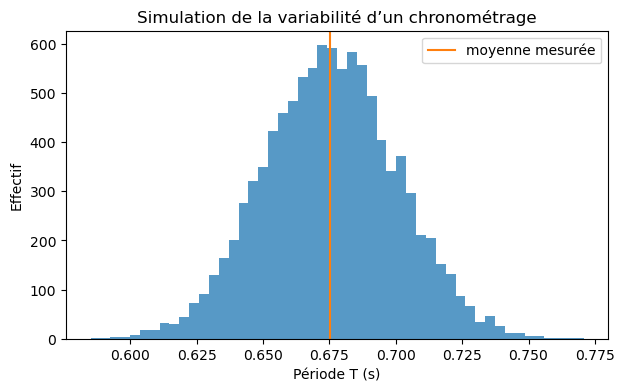

In [7]:
T_simulees = np.random.normal(T_mean, u_T_single, N)

print("Moyenne simulée =", round(T_simulees.mean(), 4), "s")
print("Écart-type simulé =", round(T_simulees.std(ddof=1), 4), "s")

plt.figure(figsize=(7, 4))
plt.hist(T_simulees, bins=50, alpha=0.75)
plt.axvline(T_mean, color="C1", label="moyenne mesurée")
plt.xlabel("Période T (s)")
plt.ylabel("Effectif")
plt.title("Simulation de la variabilité d’un chronométrage")
plt.legend()
plt.show()


## 4. Écriture du résultat de la période

Un résultat doit contenir le meilleur estimateur, son incertitude-type et leur unité commune. L’incertitude est arrondie à un ou deux chiffres significatifs ; le dernier chiffre du meilleur estimateur occupe la même position décimale.

Utilisez `round(x, n)` pour choisir le nombre de décimales adapté.


<!-- period-result-response -->
<div class="alert alert-block" style="background-color: #F5F8FC; border-color: #DCE6F0; color: #202124;">

### Résultat de la mesure de période

Présentez $T=\overline T \pm u(T)$ avec une unité et un arrondi cohérent. Commentez brièvement la dispersion observée.

### Réponse :

$T=(0{,}675 \pm 0{,}009)\,\mathrm{s}$. La dispersion des chronométrages est visible mais reste faible devant dix périodes ; la répétition permet de mieux estimer la période moyenne.
</div>


## 5. Mesure sans variabilité observable - type B

La masse suspendue porte une indication, mais sa variabilité n’est pas directement observable. On retient un intervalle $[m-\Delta m;m+\Delta m]$ dans lequel toutes les valeurs sont supposées équiprobables.

La commande `np.random.uniform(minimum, maximum, N)` permet de simuler cette distribution uniforme. Son écart-type vaut approximativement $\Delta m/\sqrt{3}$.


In [8]:
m_dyn_g = 50.0
delta_m_dyn_g = 1.0


Masse moyenne simulée = 0.05 kg
Incertitude-type simulée = 0.00058 kg


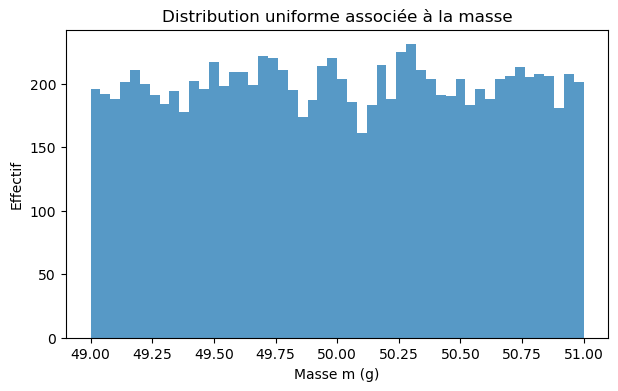

In [9]:
m_dyn_samples = np.random.uniform(
    (m_dyn_g - delta_m_dyn_g) / 1000,
    (m_dyn_g + delta_m_dyn_g) / 1000,
    N,
)

print("Masse moyenne simulée =", round(m_dyn_samples.mean(), 5), "kg")
print("Incertitude-type simulée =", round(m_dyn_samples.std(ddof=1), 5), "kg")

plt.figure(figsize=(7, 4))
plt.hist(m_dyn_samples * 1000, bins=50, alpha=0.75)
plt.xlabel("Masse m (g)")
plt.ylabel("Effectif")
plt.title("Distribution uniforme associée à la masse")
plt.show()


## 6. Comparer deux résultats : l’écart normalisé

Deux résultats $x_1\pm u(x_1)$ et $x_2\pm u(x_2)$ sont comparés avec l’écart normalisé

$$E_N=\frac{|x_1-x_2|}{\sqrt{u(x_1)^2+u(x_2)^2}}.$$

Ils sont considérés comme compatibles si $E_N<2$. Cette méthode sera appliquée à la fin du TP aux deux déterminations de la raideur $k$.


## 7. Composition des incertitudes : raideur dynamique

La théorie de l’oscillateur donne

$$\frac{2\pi}{T}=\sqrt{\frac{k}{m}}
\qquad\Longrightarrow\qquad
k=\frac{4\pi^2m}{T^2}.$$

La masse et la période possèdent chacune une incertitude. Pour les composer sans calcul différentiel, on simule des valeurs possibles de $m$ et de la période moyenne $T$, puis on calcule la valeur correspondante de $k$ pour chaque tirage.


In [10]:
T_mean_samples = np.random.normal(T_mean, u_T, N)
k_dyn_samples = 4 * np.pi**2 * m_dyn_samples / T_mean_samples**2

k_dyn = k_dyn_samples.mean()
u_k_dyn = k_dyn_samples.std(ddof=1)

# À adapter pour conserver 1 ou 2 chiffres significatifs sur u(k)
decimales_k_dyn = 2
print("k dynamique =", round(k_dyn, decimales_k_dyn), "±", round(u_k_dyn, decimales_k_dyn), "N/m")


k dynamique = 4.33 ± 0.12 N/m


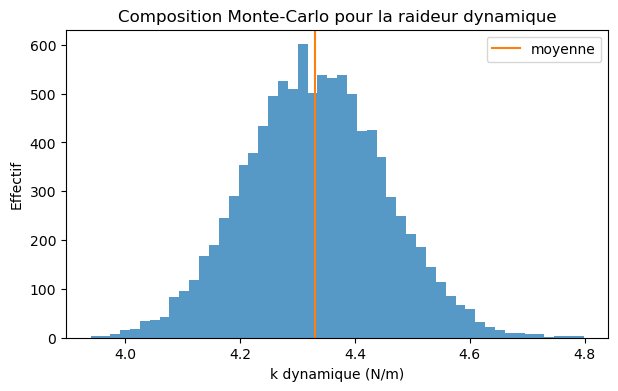

In [11]:
plt.figure(figsize=(7, 4))
plt.hist(k_dyn_samples, bins=50, alpha=0.75)
plt.axvline(k_dyn, color="C1", label="moyenne")
plt.xlabel("k dynamique (N/m)")
plt.ylabel("Effectif")
plt.title("Composition Monte-Carlo pour la raideur dynamique")
plt.legend()
plt.show()


<!-- dynamic-stiffness-interpretation-response -->
<div class="alert alert-block" style="background-color: #F5F8FC; border-color: #DCE6F0; color: #202124;">

### Raideur obtenue par la méthode dynamique

Donnez $k_\mathrm{dyn} \pm u(k_\mathrm{dyn})$, expliquez l’origine de l’incertitude et indiquez si le résultat paraît exploitable.

### Réponse :

$k_\mathrm{dyn}=(4{,}33 \pm 0{,}12)\,\mathrm{N\,m^{-1}}$. L’incertitude combine ici celle de la masse et la variabilité du chronométrage. La distribution est resserrée et le résultat est exploitable pour être comparé à la méthode statique.
</div>


## 8. Validation d’une loi affine : loi de Hooke

À l’équilibre,

$$l=\frac{mg}{k}+l_0.$$

Le modèle prévoit donc une relation affine $l=am+b$, avec $a=g/k$ et $b=l_0$. Une régression affine permet de déterminer $a$ et $b$, mais le premier contrôle reste visuel : les points doivent être alignés et proches de la droite optimale.


<!-- hooke-objective-response -->
<div class="alert alert-block" style="background-color: #F5F8FC; border-color: #DCE6F0; color: #202124;">

### Objectif de la manipulation statique

Avant les mesures, reformulez ce que le graphe doit permettre de vérifier et comment la pente donnera une seconde valeur de $k$.

### Réponse :

Vérifier expérimentalement que la longueur du ressort dépend de façon affine de la masse suspendue, conformément à la loi de Hooke. La pente $a$ du graphe $l=f(m)$ permettra ensuite de calculer une seconde raideur avec $k=g/a$.
</div>


<!-- hooke-protocol-response -->
<div class="alert alert-block" style="background-color: #F5F8FC; border-color: #DCE6F0; color: #202124;">

### Protocole statique construit en classe

Décrivez les masses utilisées, la mesure de la longueur à l’équilibre, les repères choisis, les précautions de lecture et les incertitudes retenues. Complétez votre schéma précédent ou ajoutez-en un second si nécessaire.

### Réponse :

Mesurer d’abord la longueur à vide entre les mêmes spires repères. Suspendre ensuite plusieurs masses, attendre l’équilibre et relever à chaque fois la longueur du ressort avec le réglet. Lire perpendiculairement à la graduation pour limiter la parallaxe, ne pas dépasser le domaine élastique et conserver les mêmes points de référence. Associer aux masses et aux longueurs des intervalles compatibles avec les indications des masses et la difficulté de lecture.
</div>


### Mesures des couples masse-longueur

Relevez au moins cinq couples $(m,l)$ ; une dizaine est préférable si le temps le permet. Les tableaux doivent avoir la même longueur. Conservez les mêmes repères sur le ressort et associez aux mesures des demi-largeurs cohérentes avec leur lecture.


In [12]:
m_static_g = np.array([0, 20, 50, 100, 150], dtype=float)
l_static_cm = np.array([7.3, 12.4, 18.7, 30.6, 40.5], dtype=float)
delta_m_static_g = 1.0
delta_l_static_cm = 0.3


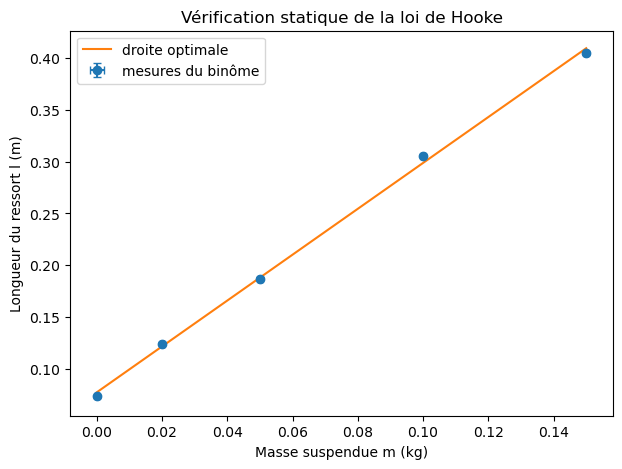

In [13]:
if len(m_static_g) != len(l_static_cm):
    raise ValueError("Les tableaux de masses et de longueurs doivent avoir la même taille.")
if len(m_static_g) < 5:
    raise ValueError("Au moins cinq couples masse-longueur sont nécessaires.")

m_static = m_static_g / 1000
l_static = l_static_cm / 100
u_m_static = (delta_m_static_g / 1000) / np.sqrt(3)
u_l_static = (delta_l_static_cm / 100) / np.sqrt(3)

a_fit, l0_fit = np.polyfit(m_static, l_static, 1)
m_line = np.linspace(m_static.min(), m_static.max(), 200)

plt.figure(figsize=(7, 5))
plt.errorbar(m_static, l_static, xerr=u_m_static, yerr=u_l_static,
             fmt="o", capsize=3, label="mesures du binôme")
plt.plot(m_line, a_fit * m_line + l0_fit, label="droite optimale")
plt.xlabel("Masse suspendue m (kg)")
plt.ylabel("Longueur du ressort l (m)")
plt.title("Vérification statique de la loi de Hooke")
plt.legend()
plt.show()


<!-- hooke-law-validation-response -->
<div class="alert alert-block" style="background-color: #F5F8FC; border-color: #DCE6F0; color: #202124;">

### Vérification de la loi de Hooke

Observez le graphe et concluez explicitement : les points expérimentaux sont-ils alignés, compte tenu de leurs incertitudes ? La loi de Hooke est-elle vérifiée dans le domaine étudié ?

### Réponse :

Les points expérimentaux sont alignés avec la droite d’ajustement, compte tenu de leurs incertitudes. La relation entre la longueur et la masse est donc affine dans le domaine étudié : la loi de Hooke est vérifiée.
</div>


In [14]:
k_static_direct = g / a_fit

print("Pente a =", round(a_fit, 3), "m/kg")
print("Ordonnée à l'origine l0 =", round(l0_fit, 3), "m")
print("k issu de la pente =", round(k_static_direct, 2), "N/m")


Pente a = 2.218 m/kg
Ordonnée à l'origine l0 = 0.077 m
k issu de la pente = 4.42 N/m


### Incertitudes sur la régression par Monte-Carlo

On simule des jeux complets de couples $(m,l)$ dans les intervalles expérimentaux, puis on recommence la régression affine. Les distributions des pentes et des ordonnées à l’origine donnent leurs meilleurs estimateurs et leurs incertitudes-types.


In [15]:
m_mc = np.random.uniform(
    m_static - delta_m_static_g / 1000,
    m_static + delta_m_static_g / 1000,
    size=(N, len(m_static)),
)
l_mc = np.random.uniform(
    l_static - delta_l_static_cm / 100,
    l_static + delta_l_static_cm / 100,
    size=(N, len(l_static)),
)

m_mc_centered = m_mc - m_mc.mean(axis=1, keepdims=True)
l_mc_centered = l_mc - l_mc.mean(axis=1, keepdims=True)
a_samples = np.sum(m_mc_centered * l_mc_centered, axis=1) / np.sum(m_mc_centered**2, axis=1)
k_static_samples = g / a_samples
k_static_samples = k_static_samples[np.isfinite(k_static_samples) & (k_static_samples > 0)]

k_static = k_static_samples.mean()
u_k_static = k_static_samples.std(ddof=1)

# À adapter pour conserver 1 ou 2 chiffres significatifs sur u(k)
decimales_k_static = 2
print("k statique =", round(k_static, decimales_k_static), "±", round(u_k_static, decimales_k_static), "N/m")


k statique = 4.42 ± 0.04 N/m


<!-- hooke-monte-carlo-lines -->
### Visualisation de l’incertitude sur l’ajustement

Chaque droite ci-dessous correspond à un jeu de masses et de longueurs compatible avec les incertitudes expérimentales. Leur dispersion permet de visualiser l’incertitude sur la pente, et donc sur la valeur de $k$ qui en est déduite. Si elles se superposent presque à cette échelle, cela signifie que l’incertitude sur la pente est faible.


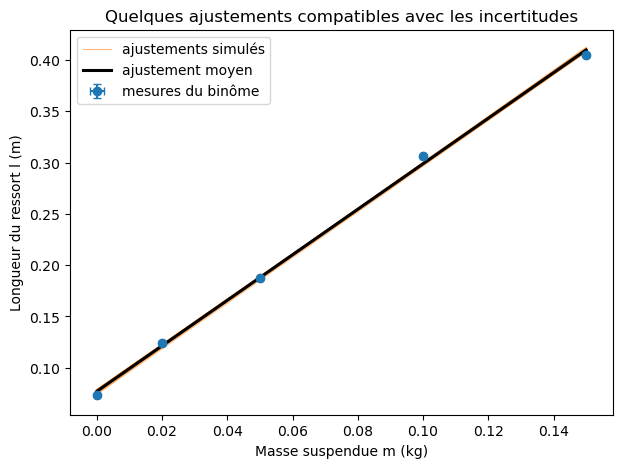

In [16]:
# Quelques ajustements affines issus de la simulation Monte-Carlo
b_samples = l_mc.mean(axis=1) - a_samples * m_mc.mean(axis=1)
selected_lines = np.linspace(0, len(a_samples) - 1, 12, dtype=int)

plt.figure(figsize=(7, 5))
for index in selected_lines:
    plt.plot(
        m_line,
        a_samples[index] * m_line + b_samples[index],
        color="C1",
        linewidth=0.8,
        alpha=0.55,
        label="ajustements simulés" if index == selected_lines[0] else None,
    )
plt.errorbar(
    m_static,
    l_static,
    xerr=u_m_static,
    yerr=u_l_static,
    fmt="o",
    capsize=3,
    color="C0",
    label="mesures du binôme",
)
plt.plot(
    m_line,
    a_samples.mean() * m_line + b_samples.mean(),
    color="black",
    linewidth=2.2,
    label="ajustement moyen",
)
plt.xlabel("Masse suspendue m (kg)")
plt.ylabel("Longueur du ressort l (m)")
plt.title("Quelques ajustements compatibles avec les incertitudes")
plt.legend()
plt.show()


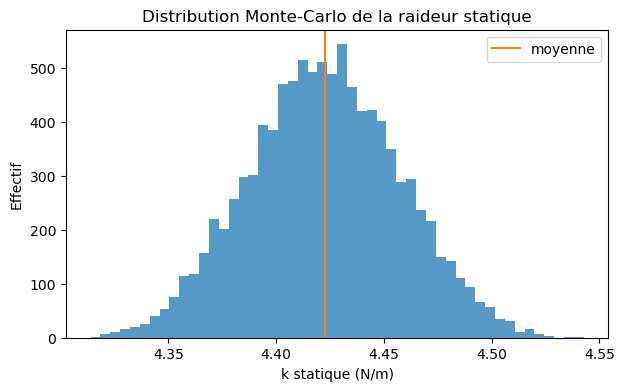

In [17]:
plt.figure(figsize=(7, 4))
plt.hist(k_static_samples, bins=50, alpha=0.75)
plt.axvline(k_static, color="C1", label="moyenne")
plt.xlabel("k statique (N/m)")
plt.ylabel("Effectif")
plt.title("Distribution Monte-Carlo de la raideur statique")
plt.legend()
plt.show()


<!-- hooke-interpretation-response -->
<div class="alert alert-block" style="background-color: #F5F8FC; border-color: #DCE6F0; color: #202124;">

### Détermination statique de la raideur

À partir de la pente de la droite, donnez le sens physique de la pente et de l’ordonnée à l’origine, puis déduisez et présentez $k_\mathrm{stat} \pm u(k_\mathrm{stat})$.

### Réponse :

La pente vaut environ $2{,}22\,\mathrm{m\,kg^{-1}}$ et correspond à $g/k$ ; l’ordonnée à l’origine, environ $7{,}7\,\mathrm{cm}$, représente la longueur à vide. On en déduit $k_\mathrm{stat}=(4{,}42 \pm 0{,}04)\,\mathrm{N\,m^{-1}}$.
</div>


## 9. Comparaison des deux déterminations de $k$

Appliquez maintenant l’écart normalisé présenté plus haut aux deux résultats $k_\mathrm{dyn}$ et $k_\mathrm{stat}$. Une éventuelle incompatibilité doit conduire à réexaminer les incertitudes, le protocole et les limites du modèle, et non à masquer le résultat.


In [18]:
E_N = abs(k_dyn - k_static) / np.sqrt(u_k_dyn**2 + u_k_static**2)

print("k dynamique =", round(k_dyn, decimales_k_dyn), "±", round(u_k_dyn, decimales_k_dyn), "N/m")
print("k statique =", round(k_static, decimales_k_static), "±", round(u_k_static, decimales_k_static), "N/m")
print("Écart normalisé =", round(E_N, 2))
print("Résultats compatibles." if E_N < 2 else "Résultats non compatibles : rechercher et discuter les causes possibles.")


k dynamique = 4.33 ± 0.12 N/m
k statique = 4.42 ± 0.04 N/m
Écart normalisé = 0.72
Résultats compatibles.


<!-- stiffness-comparison-response -->
<div class="alert alert-block" style="background-color: #F5F8FC; border-color: #DCE6F0; color: #202124;">

### Cohérence des deux valeurs de raideur

Concluez à partir de votre écart normalisé. Ne vous contentez pas de « oui » ou « non » : rappelez les deux résultats et discutez les causes expérimentales susceptibles d’expliquer leur écart.

### Réponse :

La méthode dynamique donne $(4{,}33 \pm 0{,}12)\,\mathrm{N\,m^{-1}}$ et la méthode statique $(4{,}42 \pm 0{,}04)\,\mathrm{N\,m^{-1}}$. L’écart normalisé vaut environ $0{,}71<2$ : les deux déterminations sont compatibles. Le chronométrage, le repérage des longueurs, la parallaxe et les limites du modèle du ressort peuvent expliquer l’écart résiduel.
</div>


<!-- final-conclusion-response -->
<div class="alert alert-block" style="background-color: #F5F8FC; border-color: #DCE6F0; color: #202124;">

### Conclusion générale

Rédigez une conclusion compréhensible sans le notebook : objectifs, deux résultats avec incertitudes, vérification de Hooke, comparaison quantitative et principales limites expérimentales. Ajoutez une phrase sur ce que ce TP vous a appris concernant les incertitudes et la rédaction d’un rapport.

### Réponse :

Nous avons déterminé la raideur du ressort par les oscillations, $k_\mathrm{dyn}=(4{,}33 \pm 0{,}12)\,\mathrm{N\,m^{-1}}$, puis par la pente de la loi de Hooke, $k_\mathrm{stat}=(4{,}42 \pm 0{,}04)\,\mathrm{N\,m^{-1}}$. Les mesures statiques sont compatibles avec une loi affine et l’écart normalisé $E_N\approx0{,}71$ montre que les deux valeurs sont compatibles. Les principales limites sont le temps de réaction, la lecture des longueurs et le maintien d’oscillations faibles et verticales. Ce TP montre qu’un résultat physique doit être associé à une incertitude et qu’un rapport doit relier clairement protocole, mesures, exploitation et conclusion.
</div>


## Liste d’auto-vérification avant rendu

Cette liste n’est ni une note ni une autoévaluation : elle aide simplement le binôme à vérifier que son rapport est complet.

☐ Les noms sont indiqués.  
☐ Le schéma photographié est intégré au notebook et légendé.  
☐ Les protocoles sont reformulés avec les précautions expérimentales.  
☐ Toutes les données sont celles de votre binôme et portent une unité.  
☐ Les cellules sont exécutées dans l’ordre et leurs résultats sont visibles.  
☐ Les axes des graphes sont nommés avec leurs unités.  
☐ Les deux valeurs de $k$ sont données avec leur incertitude-type.  
☐ La comparaison repose sur l’écart normalisé.  
☐ La conclusion interprète les résultats au lieu de seulement les recopier.  
☐ Le notebook peut être compris par une personne qui n’a pas assisté à la séance.
